In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

# Generate synthetic data (P2P Lending Example)
np.random.seed(42)
n_samples = 5000

data = pd.DataFrame({
    "income": np.random.normal(50000, 15000, n_samples),  # Annual income
    "credit_score": np.random.uniform(300, 850, n_samples),  # FICO score
    "loan_amount": np.random.uniform(1000, 50000, n_samples),  # Loan size
    "debt_ratio": np.random.uniform(0.1, 1, n_samples),  # Debt-to-income
    "default": np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])  # 30% default rate
})

# Splitting into train and test sets
X = data.drop(columns=["default"])
y = data["default"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [2]:
# Train Logistic Regression Model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_prob_logreg = logreg.predict_proba(X_test)[:, 1]  # Get probabilities

# Train LightGBM Model
lgb_model = lgb.LGBMClassifier(n_estimators=100)
lgb_model.fit(X_train, y_train)
y_prob_lgbm = lgb_model.predict_proba(X_test)[:, 1]  # Get probabilities

[LightGBM] [Info] Number of positive: 1211, number of negative: 2789
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.302750 -> initscore=-0.834237
[LightGBM] [Info] Start training from score -0.834237


In [3]:
auc_logreg = roc_auc_score(y_test, y_prob_logreg)
auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)

print(f"Logistic Regression AUC: {auc_logreg:.4f}")
print(f"LightGBM AUC: {auc_lgbm:.4f}")

Logistic Regression AUC: 0.4973
LightGBM AUC: 0.4746


In [4]:
gini_logreg = 2 * auc_logreg - 1
gini_lgbm = 2 * auc_lgbm - 1

print(f"Logistic Regression Gini: {gini_logreg:.4f}")
print(f"LightGBM Gini: {gini_lgbm:.4f}")

Logistic Regression Gini: -0.0054
LightGBM Gini: -0.0509


In [5]:
def ks_statistic(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    return max(tpr - fpr)

ks_logreg = ks_statistic(y_test, y_prob_logreg)
ks_lgbm = ks_statistic(y_test, y_prob_lgbm)

print(f"Logistic Regression KS: {ks_logreg:.4f}")
print(f"LightGBM KS: {ks_lgbm:.4f}")

Logistic Regression KS: 0.0238
LightGBM KS: 0.0221


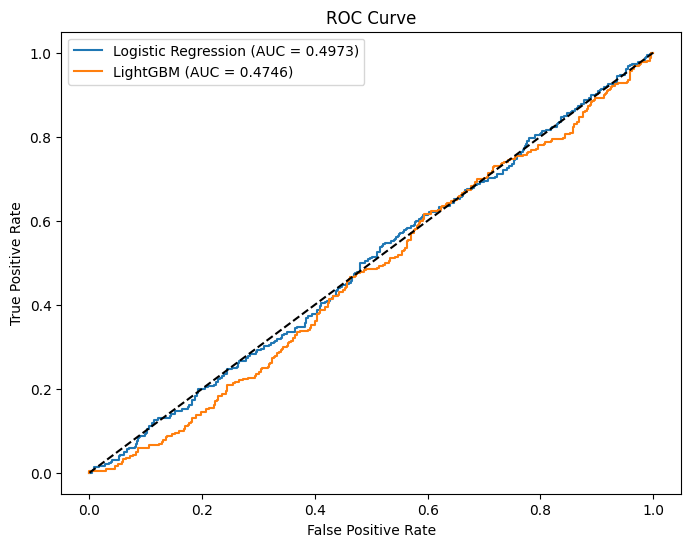

In [6]:
def plot_roc_curve(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc_score(y_true, y_prob):.4f})")
    
plt.figure(figsize=(8, 6))
plot_roc_curve(y_test, y_prob_logreg, "Logistic Regression")
plot_roc_curve(y_test, y_prob_lgbm, "LightGBM")

plt.plot([0, 1], [0, 1], 'k--')  # Random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()